# Домашнее задание 3 - NER (Named Entity Recognition)

In [1]:
!pip install -q torch torchvision torchaudio
!pip install -q datasets evaluate seqeval transformers accelerate sentencepiece huggingface_hub
!pip install -q scikit-learn seaborn matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.4 MB/s eta 0:00:00


In [2]:
import os, re, random, gc
import numpy as np
import pandas as pd
import torch
import sys
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset, DatasetDict, Dataset, Features, Sequence, Value
import evaluate

from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    DataCollatorForTokenClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    device = "cuda"
    torch.cuda.manual_seed_all(RANDOM_STATE)
elif torch.backends.mps.is_available():
    device = "mps"
    torch.mps.manual_seed(RANDOM_STATE)
else:
    device = "cpu"

print(f"Device: {device}")

Device: cuda


## 1. Загрузка датасета factRuEval-2016

In [3]:
raw_ds = load_dataset("gusevski/factrueval2016")

# Разворачиваем датасет
train_data = raw_ds["train"][0]["data"]
val_data   = raw_ds["validation"][0]["data"]
test_data  = raw_ds["test"][0]["data"]

print(f"train: {len(train_data)}, val: {len(val_data)}, test: {len(test_data)}")
print("\nПример:", train_data[0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


train_data.json:   0%|          | 0.00/7.62M [00:00<?, ?B/s]

dev_data.json:   0%|          | 0.00/2.48M [00:00<?, ?B/s]

test_data.json:   0%|          | 0.00/2.57M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1 [00:00<?, ? examples/s]

train: 7746, val: 2582, test: 2582

Пример: {'id': 0, 'tokens': ['"', 'Если', 'Миронов', 'занял', 'столь', 'оппозиционную', 'позицию', ',', 'то', 'мне', 'представляется', ',', 'что', 'для', 'него', 'было', 'бы', 'порядочным', 'и', 'правильным', 'уйти', 'в', 'отставку', 'с', 'занимаемого', 'им', 'поста', ',', 'поста', ',', 'который', 'предоставлен', 'ему', 'сегодня', '"', 'Единой', 'Россией', "''", 'и', 'никем', 'больше', "''", ',', '-', 'заключает', 'Исаев', '.'], 'length': 47, 'ner_tags_str': ['O', 'O', 'B-PER', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-ORG', 'I-ORG', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-PER', 'O'], 'ner_tags': [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 4, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0]}


## 2. Подготовка данных

In [4]:
MODEL_ID = "deepvk/RuModernBERT-small"

# Токенизация и выравнивание меток (по аналогии с семинаром)
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

label_names = ["O", "B-PER", "I-PER", "B-ORG", "I-ORG", "B-LOC", "I-LOC"]
label2id = {l: i for i, l in enumerate(label_names)}
id2label  = {i: l for i, l in enumerate(label_names)}

print("label2id:", label2id)

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/837 [00:00<?, ?B/s]

label2id: {'O': 0, 'B-PER': 1, 'I-PER': 2, 'B-ORG': 3, 'I-ORG': 4, 'B-LOC': 5, 'I-LOC': 6}


In [5]:
# Собираем DatasetDict с feature types
features = Features({
    "tokens":       Sequence(Value("string")),
    "ner_tags":     Sequence(Value("int32")),
})

def to_hf_dataset(data):
    return Dataset.from_dict(
        {
            "tokens":   [item["tokens"] for item in data],
            "ner_tags": [[int(t) for t in item["ner_tags"]] for item in data],
        },
        features=features,
    )

ds = DatasetDict({
    "train":      to_hf_dataset(train_data),
    "validation": to_hf_dataset(val_data),
    "test":       to_hf_dataset(test_data),
})
print(ds)
print("features:", ds["train"].features)

DatasetDict({
    train: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 7746
    })
    validation: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 2582
    })
    test: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 2582
    })
})
features: {'tokens': List(Value('string')), 'ner_tags': List(Value('int32'))}


In [6]:
def tokenize_and_align_labels(examples, max_length=192):
    # токенизируем уже разбитые на слова последовательности
    tokenized = tokenizer(
        examples["tokens"],
        is_split_into_words=True,
        truncation=True,
        max_length=max_length,
    )
    aligned_labels = []
    # Для игнорирования субтокенов и спецтокенов ставим им вес -100
    # - принятый формат игнорирования при расчете Loss
    for i in range(len(examples["tokens"])):
        word_ids = tokenized.word_ids(batch_index=i)
        gold = examples["ner_tags"][i]
        prev, out = None, []
        for w in word_ids:
            if w is None:
                out.append(-100)
            elif w != prev:
                out.append(gold[w])
            else:
                out.append(-100)
            prev = w
        aligned_labels.append(out)
    tokenized["labels"] = aligned_labels
    return tokenized

tokenized = ds.map(
    lambda x: tokenize_and_align_labels(x),
    batched=True,
)
print(tokenized)
print("labels[0][:15]:", tokenized["train"][0]["labels"][:15])

Map:   0%|          | 0/7746 [00:00<?, ? examples/s]

Map:   0%|          | 0/2582 [00:00<?, ? examples/s]

Map:   0%|          | 0/2582 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['tokens', 'ner_tags', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 7746
    })
    validation: Dataset({
        features: ['tokens', 'ner_tags', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 2582
    })
    test: Dataset({
        features: ['tokens', 'ner_tags', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 2582
    })
})
labels[0][:15]: [-100, 0, 0, 1, -100, -100, 0, -100, -100, 0, -100, 0, -100, -100, 0]


## 3. Baseline: fine-tuning энкодера на NER

In [7]:
import evaluate
seqeval_metric = evaluate.load("seqeval")
ENTITY_TYPES = ("PER", "ORG", "LOC")
results_table = []  # сюда будем складывать результаты всех экспериментов

# Переход от BIO формата к спанам (start, end, type)
def bio_to_spans(labels):
    spans, start, ent_type = [], None, None
    for i, lab in enumerate(labels):
        if lab == "O":
            if ent_type is not None:
                spans.append((start, i, ent_type))
                start, ent_type = None, None
        else:
            prefix, typ = lab.split("-", 1)
            if prefix == "B":
                if ent_type is not None:
                    spans.append((start, i, ent_type))
                start, ent_type = i, typ
            elif prefix == "I" and ent_type is None:
                start, ent_type = i, typ
    if ent_type is not None:
        spans.append((start, len(labels), ent_type))
    return spans

# Считае seqeval f1/precision/recall, игнорируя 0й класс
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    y_true, y_pred = [], []
    for p, l in zip(preds, labels):
        true_labels, pred_labels = [], []
        for pi, li in zip(p, l):
            if li == -100:
                continue
            true_labels.append(id2label[li])
            pred_labels.append(id2label[pi])
        y_true.append(true_labels)
        y_pred.append(pred_labels)
    res = seqeval_metric.compute(predictions=y_pred, references=y_true, zero_division=0)
    return {"f1": res["overall_f1"], "precision": res["overall_precision"], "recall": res["overall_recall"]}


def trainer_to_seqeval(pred_output):
    preds = np.argmax(pred_output.predictions, axis=-1)
    labels = pred_output.label_ids
    y_true, y_pred = [], []
    for p, l in zip(preds, labels):
        true_labels, pred_labels = [], []
        for pi, li in zip(p, l):
            if li == -100:
                continue
            true_labels.append(id2label[li])
            pred_labels.append(id2label[pi])
        y_true.append(true_labels)
        y_pred.append(pred_labels)
    return y_true, y_pred

# Строим confusion matrix по сущностям
def confusion_matrix_by_type(y_true, y_pred, entity_types=ENTITY_TYPES):
    idx = {t: i for i, t in enumerate(entity_types)}
    cm = np.zeros((len(entity_types), len(entity_types)), dtype=int)
    for gt, pr in zip(y_true, y_pred):
        gb = {(s, e): t for s, e, t in bio_to_spans(gt)}
        pb = {(s, e): t for s, e, t in bio_to_spans(pr)}
        for b in set(gb) & set(pb):
            g, p = gb[b], pb[b]
            if g in idx and p in idx:
                cm[idx[g], idx[p]] += 1
    return cm, list(entity_types)


def plot_confusion(cm, labels, title):
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
    plt.title(title)
    plt.xlabel("pred")
    plt.ylabel("gold")
    plt.tight_layout()
    plt.show()


def summarize(name, y_true, y_pred):
    res = seqeval_metric.compute(predictions=y_pred, references=y_true, zero_division=0)
    return {
        "model":     name,
        "f1":        round(res["overall_f1"], 4),
        "precision": round(res["overall_precision"], 4),
        "recall":    round(res["overall_recall"], 4),
    }

In [8]:
data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer, padding="longest")

# Загружаем предобученную модель со случайной NER головой на 7 классов
# ORG, LOC, PER * 2 (I / B) + 0 = 7
model = AutoModelForTokenClassification.from_pretrained(
    MODEL_ID,
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id,
).to(device)

# Мерим f1 до обучения
pre_trainer = Trainer(
    model=model,
    args=TrainingArguments(
        output_dir="tmp_eval",
        per_device_eval_batch_size=8,
        fp16=True,
        report_to="none",
    ),
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)
preds_before = pre_trainer.predict(tokenized["test"])
y_true_before, y_pred_before = trainer_to_seqeval(preds_before)
results_table.append(summarize("RuModernBERT-small (до)", y_true_before, y_pred_before))
print("F1 до обучения:", results_table[-1]["f1"])

del pre_trainer
gc.collect()
if device == "mps": torch.mps.empty_cache()

model.safetensors:   0%|          | 0.00/138M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

ModernBertForTokenClassification LOAD REPORT from: deepvk/RuModernBERT-small
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.weight | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
W0329 17:37:41.578000 2040 torch/_inductor/utils.py:1679] [1/0_1] Not enough SMs to use max_autotune_gemm mode


F1 до обучения: 0.0378


In [9]:
# Warm-up: обучаем только NER голову на большом lr, энкодер морозим
# Делаем это, чтобы не сломать обученный энкодер большим lr - его будем обучать после этого с низким lr
for p in model.base_model.parameters():
    p.requires_grad = False

trainer_warmup = Trainer(
    model=model,
    args=TrainingArguments(
        output_dir="ner_warmup",
        learning_rate=5e-4,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        num_train_epochs=5,
        fp16=True,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        report_to="none",
    ),
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)
trainer_warmup.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': None, 'bos_token_id': None}.


Epoch,Training Loss,Validation Loss,F1,Precision,Recall
1,No log,0.188221,0.641742,0.610344,0.676545
2,0.264924,0.191341,0.613945,0.611410,0.616502
3,0.175318,0.166564,0.656036,0.636049,0.677319
4,0.161470,0.161605,0.695910,0.667616,0.726709
5,0.151478,0.159782,0.696420,0.669707,0.725353


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2425, training_loss=0.18099656724438226, metrics={'train_runtime': 83.8512, 'train_samples_per_second': 461.89, 'train_steps_per_second': 28.92, 'total_flos': 328469686576416.0, 'train_loss': 0.18099656724438226, 'epoch': 5.0})

In [10]:
# Fine-tune: размораживаем энкоден и дообучаем всю модель с небольшим lr
for p in model.base_model.parameters():
    p.requires_grad = True

trainer = Trainer(
    model=model,
    args=TrainingArguments(
        output_dir="ner_finetuned",
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        num_train_epochs=10,
        fp16=True,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        warmup_ratio=0.1,
        weight_decay=0.01,
        report_to="none",
    ),
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)
trainer.train()

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,F1,Precision,Recall
1,No log,0.064308,0.884944,0.859044,0.912454
2,0.090525,0.050863,0.920644,0.911212,0.930273
3,0.037590,0.046283,0.938870,0.931883,0.945962
4,0.016905,0.053079,0.943124,0.937261,0.949061
5,0.005604,0.067060,0.941652,0.936244,0.947124
6,0.002119,0.067704,0.946053,0.939458,0.952741
7,0.000772,0.069831,0.947328,0.943686,0.950997
8,0.000558,0.071795,0.946973,0.941086,0.952934
9,0.000239,0.074250,0.948068,0.943252,0.952934
10,0.000044,0.074724,0.947318,0.942146,0.952547


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=4850, training_loss=0.015917385654120715, metrics={'train_runtime': 344.9489, 'train_samples_per_second': 224.555, 'train_steps_per_second': 14.06, 'total_flos': 657034225190112.0, 'train_loss': 0.015917385654120715, 'epoch': 10.0})

In [11]:
# Мерим f1 после дообучения
preds = trainer.predict(tokenized["test"])
y_true, y_pred = trainer_to_seqeval(preds)
results_table.append(summarize("RuModernBERT-small (после)", y_true, y_pred))

pd.DataFrame(results_table)

,model,f1,precision,recall
0,RuModernBERT-small (до),0.0378,0.0222,0.1281
1,RuModernBERT-small (после),0.9540,0.9493,0.9588


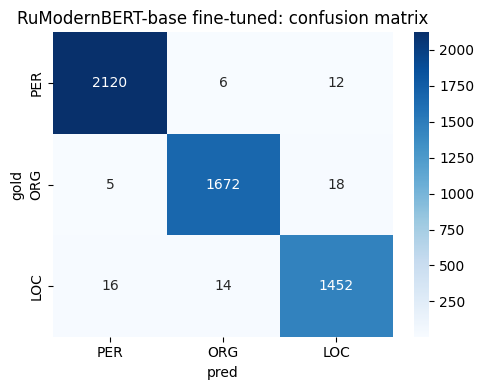

In [12]:
cm, cm_labels = confusion_matrix_by_type(y_true, y_pred)
plot_confusion(cm, cm_labels, "RuModernBERT-small fine-tuned: confusion matrix")

## 4. MLM pre-training + NER fine-tuning

In [13]:
import gc, torch
gc.collect()
torch.cuda.empty_cache()


In [14]:
from transformers import AutoModelForMaskedLM, DataCollatorForLanguageModeling

# Для MLM метки не нужны, поэтому токенизируем просто текст и убираем NER колонки
def tokenize_for_mlm(examples, max_length=192):
    texts = [" ".join(tokens) for tokens in examples["tokens"]]
    return tokenizer(texts, truncation=True, max_length=max_length)

mlm_dataset = ds.map(
    tokenize_for_mlm,
    batched=True,
    remove_columns=ds["train"].column_names,
)

# Маскируем 15% токенов
mlm_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=True,
    mlm_probability=0.15,
)

# Загружаем чистый энкодер без NER головы
mlm_model = AutoModelForMaskedLM.from_pretrained(MODEL_ID).to(device)

mlm_trainer = Trainer(
    model=mlm_model,
    args=TrainingArguments(
        output_dir="ner_mlm_pretrain",
        learning_rate=5e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=3,
        fp16=True,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        report_to="none",
    ),
    train_dataset=mlm_dataset["train"],
    eval_dataset=mlm_dataset["validation"],
    data_collator=mlm_collator,
)

mlm_trainer.train()

Map:   0%|          | 0/7746 [00:00<?, ? examples/s]

Map:   0%|          | 0/2582 [00:00<?, ? examples/s]

Map:   0%|          | 0/2582 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/77 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss
1,No log,1.766951
2,1.740649,1.713179
3,1.544573,1.661507


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['decoder.weight'].


TrainOutput(global_step=1455, training_loss=1.5825259074312714, metrics={'train_runtime': 170.4743, 'train_samples_per_second': 136.314, 'train_steps_per_second': 8.535, 'total_flos': 148160606246400.0, 'train_loss': 1.5825259074312714, 'epoch': 3.0})

In [16]:
# Находим лучший чекпоинт и грузим веса энкодера через state_dict
import os, glob

def load_encoder_from_mlm_checkpoint(checkpoint_dir, ner_model):
    # Ищем файл с весами в папке чекпоинта
    candidates = glob.glob(os.path.join(checkpoint_dir, "**", "model.safetensors"), recursive=True)
    if not candidates:
        candidates = glob.glob(os.path.join(checkpoint_dir, "**", "pytorch_model.bin"), recursive=True)
    assert candidates, f"Не найдены веса в {checkpoint_dir}"
    ckpt_path = candidates[0]
    print(f"Загружаем веса из: {ckpt_path}")

    if ckpt_path.endswith(".safetensors"):
        from safetensors.torch import load_file
        state = load_file(ckpt_path, device="cpu")
    else:
        state = torch.load(ckpt_path, map_location="cpu")

    # Оставляем только веса энкодера (без MLM-головы)
    encoder_prefix = ner_model.base_model_prefix + "."
    encoder_state = {
        k[len(encoder_prefix):]: v
        for k, v in state.items()
        if k.startswith(encoder_prefix)
    }
    missing, unexpected = ner_model.base_model.load_state_dict(encoder_state, strict=False)
    print(f"Missing keys: {len(missing)}, Unexpected: {len(unexpected)}")
    return ner_model

mlm_ner_model = AutoModelForTokenClassification.from_pretrained(
    MODEL_ID,
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id,
)
mlm_ner_model = load_encoder_from_mlm_checkpoint("ner_mlm_pretrain", mlm_ner_model)
mlm_ner_model = mlm_ner_model.to(device)

del mlm_model, mlm_trainer
gc.collect()
torch.cuda.empty_cache()

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

ModernBertForTokenClassification LOAD REPORT from: deepvk/RuModernBERT-small
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.weight | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Загружаем веса из: ner_mlm_pretrain/checkpoint-1455/model.safetensors
Missing keys: 0, Unexpected: 0


In [17]:
# Warm-up головы
for p in mlm_ner_model.base_model.parameters():
    p.requires_grad = False

trainer_mlm_warmup = Trainer(
    model=mlm_ner_model,
    args=TrainingArguments(
        output_dir="ner_mlm_warmup",
        learning_rate=5e-4,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        gradient_accumulation_steps=2,
        num_train_epochs=5,
        fp16=True,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        report_to="none",
    ),
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)
trainer_mlm_warmup.train()

# Fine-tune всей модели
for p in mlm_ner_model.base_model.parameters():
    p.requires_grad = True

trainer_mlm = Trainer(
    model=mlm_ner_model,
    args=TrainingArguments(
        output_dir="ner_mlm_finetuned",
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        gradient_accumulation_steps=2,
        num_train_epochs=10,
        fp16=True,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        warmup_ratio=0.1,
        weight_decay=0.01,
        report_to="none",
    ),
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)
trainer_mlm.train()

preds_mlm = trainer_mlm.predict(tokenized["test"])
y_true_mlm, y_pred_mlm = trainer_to_seqeval(preds_mlm)
results_table.append(summarize("RuModernBERT-small + MLM", y_true_mlm, y_pred_mlm))
pd.DataFrame(results_table)

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': None, 'bos_token_id': None}.


Epoch,Training Loss,Validation Loss,F1,Precision,Recall
1,No log,0.199649,0.667716,0.639752,0.698237
2,No log,0.167004,0.676709,0.658362,0.696107
3,0.575034,0.164480,0.691131,0.670430,0.713151
4,0.575034,0.157730,0.700162,0.688178,0.712570
5,0.297905,0.155075,0.709914,0.688832,0.732326


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

,model,f1,precision,recall
0,RuModernBERT-small (до),0.0378,0.0222,0.1281
1,RuModernBERT-small (после),0.9540,0.9493,0.9588
2,RuModernBERT-base + MLM,0.9495,0.9470,0.9519


## 5. Сравнение подходов и выводы

In [26]:
pd.DataFrame(results_table)

,model,f1,precision,recall
0,RuModernBERT-small (до),0.0378,0.0222,0.1281
1,RuModernBERT-small (после),0.9540,0.9493,0.9588
2,RuModernBERT-small + MLM,0.9495,0.9470,0.9519


### Выводы

1. Базовая модель (до обучения) - f1 ~0.04 двет просто случайные предикты. Голова инициализирована случайно, энкодер хоть и понимает язык, но еще не знает что делать с NER

2. После дообучения - f1 ~0.954. Прирост огромный, большая часть качества приходит именно от fine tuning на задачу

3. MLM -> NER (domain adaptation) - f1 ~0.950. Чуть хуже чем обычный fine tune.
Скорее всего это связано с тем, что factRuEval - новостные тексты, а RuModernBERT-small уже обучен на похожих данных. Наш MLM на том же домене не дал значимого буста, а только добавил шума в веса

Кажется, что для хорошо предобученных моделей дополнительный MLM на домене оправдан, если домен довольно сильно отличается. Для остальных кейсов простой fine tune работает не хуже